In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:

import numpy as np


In [3]:
from sklearn.linear_model import Perceptron


In [4]:
from sklearn.metrics import accuracy_score

In [5]:
import matplotlib.pyplot as plt

In [6]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

from shared import utils

In [7]:
iris = datasets.load_iris()
X = iris.data[:, [2,3]]
y = iris.target


In [8]:
print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y) # stratify ensures that the proportion of each class is maintained in both training and testing sets


In [10]:
sc = StandardScaler()
sc.fit(X_train)

StandardScaler()

In [11]:
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [12]:
ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [13]:
y_pred = ppn.predict(X_test_std)

In [14]:
print('Misclassified examples: %d' % (y_test != y_pred).sum())

Misclassified examples: 1


In [15]:
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))

Accuracy: 0.978


In [16]:
print(X_train_std.shape)
print(X_test_std.shape)
print(y_train.shape)
print(y_test.shape)

(105, 2)
(45, 2)
(105,)
(45,)


In [17]:
print(X_train_std[:10])


[[-1.33269725 -1.30728421]
 [-1.16537974 -1.30728421]
 [ 0.84243039  1.44587881]
 [ 1.0655204   1.18367281]
 [-1.44424226 -1.30728421]
 [ 1.0097479   1.57698181]
 [ 1.56747294  1.18367281]
 [-1.44424226 -1.30728421]
 [ 1.12129291  0.5281578 ]
 [ 0.45202286  0.1348488 ]]


In [18]:
print(y_train[:10])

[0 0 2 2 0 2 2 0 2 1]


In [19]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

In [20]:
print(X_combined_std.shape)
print(y_combined.shape)

(150, 2)
(150,)


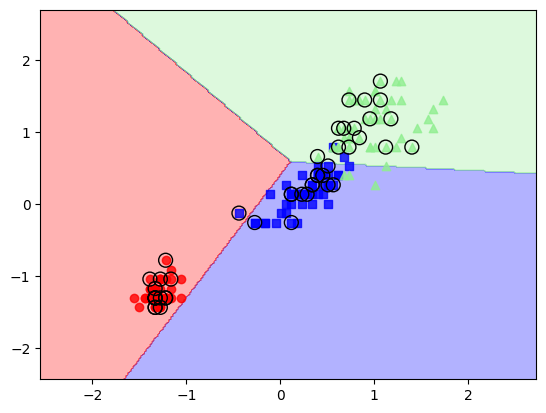

<function matplotlib.pyplot.show(close=None, block=None)>

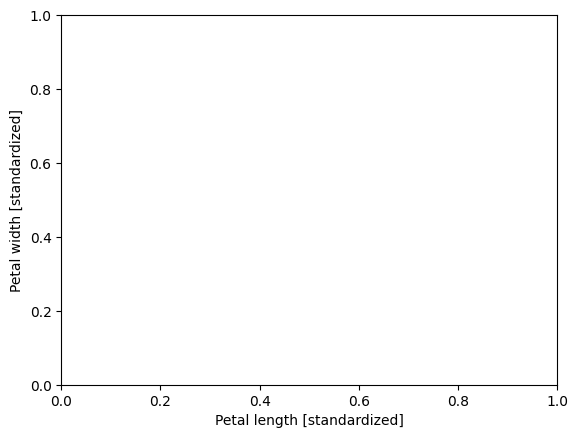

In [21]:
utils.plot_decision_regions(X=X_combined_std, y=y_combined, classifier=ppn, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend
plt.tight_layout
plt.show

In [22]:
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

In [23]:
import logistic_regression

In [24]:
lrg = logistic_regression.LogisticRegression(eta = 0.3, num_epochs = 1000, random_state=1)
lrg.fit(X_train_01_subset, y_train_01_subset)

/home/sgupta/Projects/random_projects/random-projects/ml_with_pytorch_raschka/ch3/logistic_regression.py:64: RuntimeWarning: divide by zero encountered in log
  loss = (-yi*np.log(output)) - ((1.0-yi) * np.log(1.0 - output))
/home/sgupta/Projects/random_projects/random-projects/ml_with_pytorch_raschka/ch3/logistic_regression.py:64: RuntimeWarning: invalid value encountered in scalar multiply
  loss = (-yi*np.log(output)) - ((1.0-yi) * np.log(1.0 - output))


In [25]:
print(lrg.w)

[0.30243607 0.23099158]


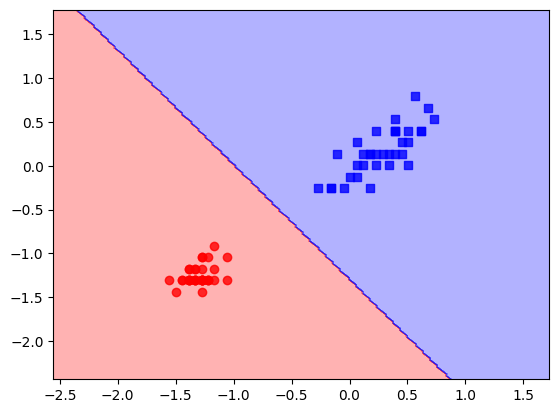

/tmp/ipykernel_1276466/4106295904.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


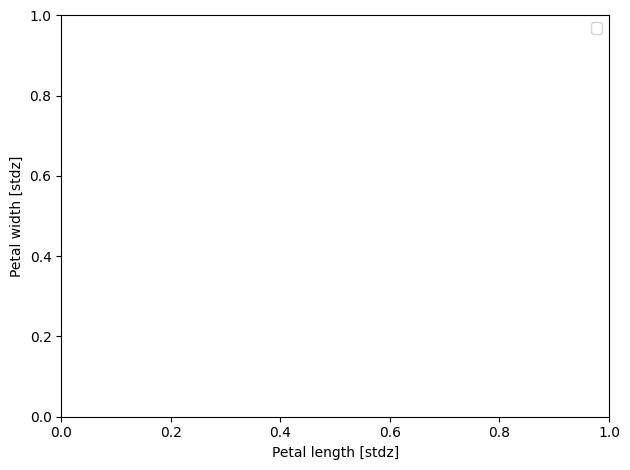

In [26]:
utils.plot_decision_regions(X_train_01_subset, y_train_01_subset, classifier=lrg)
plt.xlabel('Petal length [stdz]')
plt.ylabel('Petal width [stdz]')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
np.random.seed(1)

In [28]:
X_xor = np.random.randn(200, 2)
print(X_xor[:5])

[[ 1.62434536 -0.61175641]
 [-0.52817175 -1.07296862]
 [ 0.86540763 -2.3015387 ]
 [ 1.74481176 -0.7612069 ]
 [ 0.3190391  -0.24937038]]


In [ ]:
# XOR is True, True = False, True, False = True, False, True = True, False, False = False
first = X_xor[:, 0] > 0 # sets values where val > 0 to True and val < 0 to False
second = X_xor[:, 1] > 1 # same as above


In [32]:
print(X_xor[:, 0][:10])
print(first[:10])

[ 1.62434536 -0.52817175  0.86540763  1.74481176  0.3190391   1.46210794
 -0.3224172   1.13376944 -0.17242821  0.04221375]
[ True False  True  True  True  True False  True False  True]


In [33]:
#Logical xor them 
y_xor = np.logical_xor(first, second)

In [34]:
print(y_xor[:10])

[ True False  True  True  True  True False  True False  True]


In [35]:
y_xor = np.where(y_xor, 1, 0)
print(y_xor[:10])

[1 0 1 1 1 1 0 1 0 1]


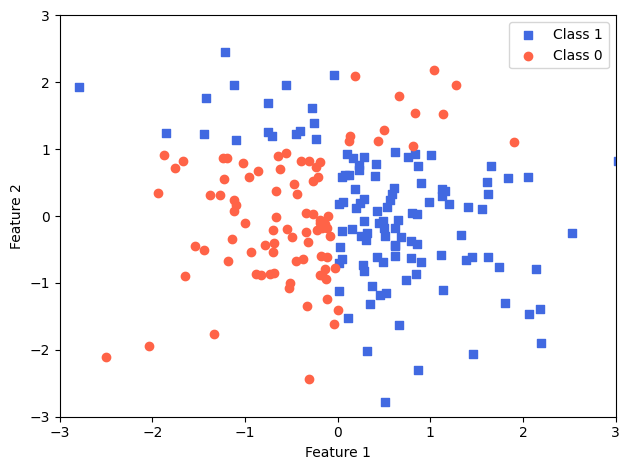

In [37]:
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='royalblue', marker='s', label='Class 1')
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='tomato', marker='o', label='Class 0')
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

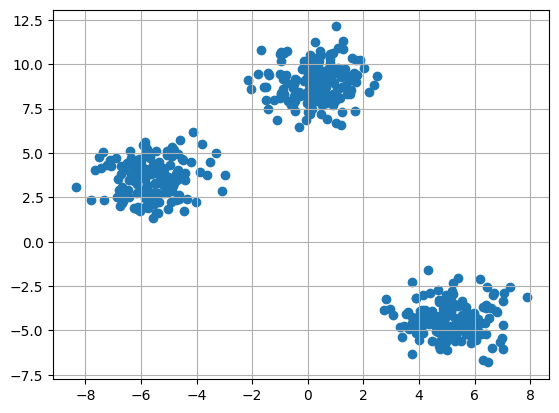

In [39]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [46]:
print(X.shape)

(500, 2)


In [47]:
print(X[:20])
print(max(X[:, 0]))
print(max(X[:, 1]))

[[-1.0889999   0.14488353]
 [-1.05420498  0.43346165]
 [-1.10123732  0.07800026]
 [ 1.43719599 -1.12554682]
 [-1.45695691 -0.07386225]
 [-1.46985571  0.0653728 ]
 [-0.15109738  1.4417686 ]
 [ 1.41217356 -1.68724969]
 [ 0.08417644  1.25007291]
 [ 0.05378339  1.32851512]
 [ 0.05934423  1.34194884]
 [ 0.09248376  1.02740016]
 [-1.23941278  0.1981175 ]
 [-1.33092948  0.01853151]
 [-1.39680591  0.35816048]
 [-1.35162802 -0.15685059]
 [-1.33588134  0.30866262]
 [ 0.13978222  1.15647284]
 [-1.1785735   0.29245045]
 [ 1.02384935 -1.32917536]]
1.7583231089901792
1.6866152571078084


In [ ]:
print(y.shape)


(500,)


In [51]:
print(X.shape[1])

2


In [53]:
print([0,1] == [1,0])
print([0,1] == [0,1])

False
True


In [ ]:
from collections import defaultdict

In [ ]:
def getRandomCentroids(k: int, num_features: int):
    return np.array([5*(2*np.random.random((num_features,))-1)] * k) # random points of size 2 between -5 and 5


In [ ]:
random_Centroids = getRandomCentroids(3, 2)
print()


3


In [57]:
print(X[0,0], X[0,1])

-1.088999895971755 0.14488352829081114


In [ ]:
# get random 2d points
# k clusters
# num_iterations

def k_means(k, dataset, max_iterations):
    numFeatures = X.shape[1]
    centroids = np.array(getRandomCentroids(k, numFeatures))

    iterations = 0
    oldCentroids = None

    while (oldCentroids is not centroids) and (iterations <= max_iterations):
        oldCentroid = centroids
        iterations += 1

        labels = defaultdict(int)
        for x1, x2 in dataset:
            for n in range(k):
                label = np.sqrt((centroids[k][0] - x1)**2 + (centroids[k][1])**2)


    
